<a href="https://colab.research.google.com/github/marquinholol1/projeto_marcos_entropia/blob/main/entro_py_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Revisão sistemática

Revisão sistemática da Literatura (RSL) sobre o uso do python no ensino de Física no cenario Brasileiro

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importando os dados para um DataFrame pandas
url = "https://raw.githubusercontent.com/PiresMA/colab/refs/heads/main/discentes/tab_pyt_fis.txt"
df = pd.read_csv(url, delimiter="\t")

#print(df.head())
#print(list(df.columns))

# Colunas a serem modificadas
colunas = ['Mec', 'Ondul', 'Opt', 'Termo', 'Elet', 'FisMod']

# Aplicando a substituição e conversão
df[colunas] = df[colunas].replace({"X": 1, np.nan: 0}).astype(int)

print(df.head())


    Ano  Mec  Ondul  Opt  Termo  Elet  FisMod Outra  Antes Durant Depois
0  2015    0      0    0      1     1       0   NaN    NaN    NaN    NaN
1  2017    0      0    0      0     1       0   NaN    NaN    NaN    NaN
2  2017    0      0    0      0     1       0   NaN    NaN    NaN    NaN
3  2018    1      0    0      0     0       0   NaN    NaN    NaN    NaN
4  2018    0      1    0      0     0       0   NaN    NaN    NaN      X


<ipython-input-9-763200a16d22>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas] = df[colunas].replace({"X": 1, np.nan: 0}).astype(int)


Mec       25
Elet       9
Termo      5
Ondul      5
Opt        3
FisMod     2
dtype: int64


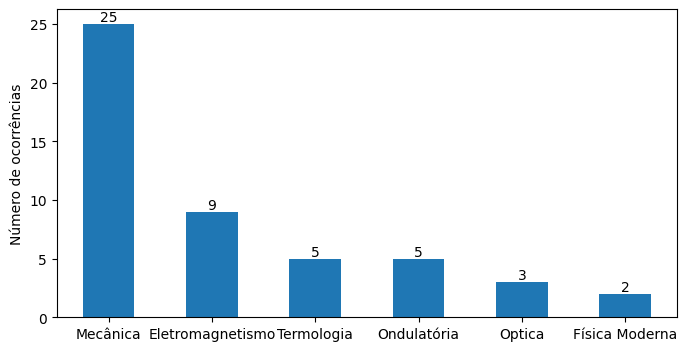

In [ ]:
colunas2 = ['Mec', 'Elet', 'Termo', 'Ondul', 'Opt', 'FisMod']

#Nomes completos
colunas_completas = ['Mecânica', 'Eletromagnetismo', 'Termologia', 'Ondulatória', 'Optica', 'Física Moderna']

# Contando os 1s em cada coluna
contagem_1s = df[colunas2].sum()
print(contagem_1s)

# Criando o gráfico de barras com os novos nomes
plt.figure(figsize=(8, 4))
contagem_1s.plot(kind='bar') #plt.title('Contagem de "1" em cada disciplina') #plt.xlabel('Disciplinas')
plt.ylabel('Número de ocorrências')
plt.xticks(ticks=range(len(colunas_completas)), labels=colunas_completas, rotation=0);

# Adicionando rótulos com os valores numéricos
for i, v in enumerate(contagem_1s):
    plt.text(i, v+0.2, str(v), ha='center')


# Legenda: Número de ocorrências por área dos trabalhos que empregaram o Python como ferramente de apoio ao ensino de Física no Brasil.
# Resultados obtidos após uma busca sistemática em diversas bases acadêmicas
# (Periódicos/CAPES, Catálogo de Teses & Dissertações (CTD) da CAPES,
# Biblioteca Digital Brasileira de Teses e Dissertações (BDTD), google acadêmico e Oasis/BR)


#Tabela inicial probabiblidades (Shannon)

,Evento,P(10),P(2),Entropia de Shannon
0,Evento 1,1.0,0.0,-0.000000
1,Evento 2,0.9,0.1,0.325083
2,Evento 3,0.8,0.2,0.500402
3,Evento 4,0.7,0.3,0.610864
4,Evento 5,0.6,0.4,0.673012
5,Evento 6,0.5,0.5,0.693147
6,Evento 7,0.4,0.6,0.673012
7,Evento 8,0.3,0.7,0.610864
8,Evento 9,0.2,0.8,0.500402
9,Evento 10,0.1,0.9,0.325083


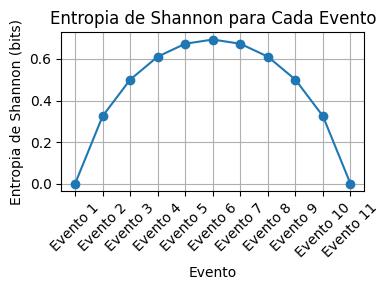

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Função para calcular a entropia de Shannon
def shannon_entropy(probabilities):
    return -np.sum([p * np.log(p) if p > 0 else 0 for p in probabilities])

# Criação da tabela de eventos e cálculo da entropia
events = []
entropies = []
probabilities_10 = []
probabilities_2 = []

for i in range(11):
    prob_10 = 1 - i * 0.1
    prob_2 = 1 - prob_10
    entropy = shannon_entropy([prob_10, prob_2])

    events.append(f'Evento {i+1}')
    probabilities_10.append(prob_10)
    probabilities_2.append(prob_2)
    entropies.append(entropy)

# Criar um DataFrame com os resultados
df = pd.DataFrame({
    'Evento': events,
    'P(10)': probabilities_10,
    'P(2)': probabilities_2,
    'Entropia de Shannon': entropies
})

# Display the dataframe using the display function
display(df)

# Gerar o gráfico da entropia de Shannon
plt.figure(figsize=(4, 3))
plt.plot(events, entropies, marker='o')
plt.title('Entropia de Shannon para Cada Evento')
plt.xlabel('Evento')
plt.ylabel('Entropia de Shannon (bits)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

#Exemplos de aplicação

##Sistema de partículas com dois níveis de energia

### Figura 4.5 salinas (Exemplo)

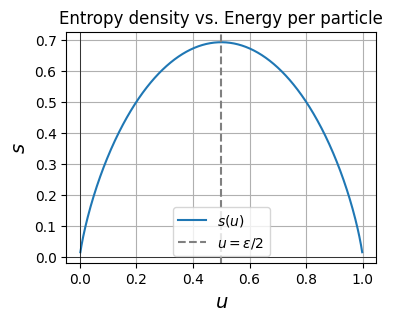

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
k_B = 1  # Boltzmann constant (in arbitrary units)
epsilon = 1  # Energy level difference (in arbitrary units)

# Function for entropy per particle
def entropy_density(u, epsilon=1):
    if u == 0 or u == epsilon:
        return -np.inf  # Handles the ln(0) issue
    term1 = (1 - u/epsilon) * np.log(1 - u/epsilon)
    term2 = u/epsilon * np.log(u/epsilon)
    return -k_B * (term1 + term2)

# Generate the values for u
u_values = np.linspace(0, epsilon, 500)

# Calculate entropy per particle for each u
s_values = [entropy_density(u) for u in u_values]

# Plotting
plt.figure(figsize=(4, 3))
plt.plot(u_values, s_values, label=r'$s(u)$')
plt.xlabel(r'$u$', fontsize=14)
plt.ylabel(r'$s$', fontsize=14)
plt.title('Entropy density vs. Energy per particle')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.axvline(epsilon/2, color='gray', linestyle='--', label=r'$u = \epsilon/2$')
plt.legend()
plt.show()


### Entropia vs nº de partículas

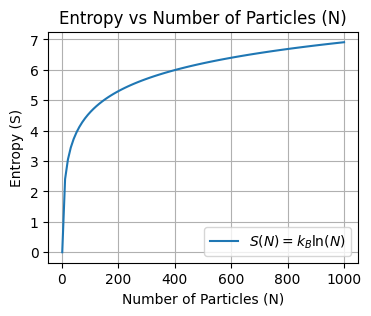

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Let's create a range of N values and plot the entropy as a function of N
N_range = np.linspace(1, 1000, 100)  # From 1 to 1000 particles

# Boltzmann constant (in arbitrary units) - defining it here so it's accessible
k_B = 1

# Assuming a logarithmic relationship for entropy as a function of N
S_N_values = k_B * np.log(N_range)

# Plotting Entropy as a function of N
plt.figure(figsize=(4, 3))
plt.plot(N_range, S_N_values, label=r'$S(N) = k_B \ln(N)$')
plt.title('Entropy vs Number of Particles (N)')
plt.xlabel('Number of Particles (N)')
plt.ylabel('Entropy (S)')
plt.grid(True)
plt.legend()
plt.show()



### Variância da distribuição

In [ ]:
import sympy as sp

# Definindo as variáveis
u, epsilon = sp.symbols('u epsilon')

# Expressão da densidade de entropia s(u)
s = -sp.Symbol('k_B') * ((1 - u/epsilon) * sp.log(1 - u/epsilon) + (u/epsilon) * sp.log(u/epsilon))

# Segunda derivada de s(u) em relação a u
second_derivative_s = sp.diff(s, u, u)

# Simplificação da expressão
second_derivative_s_simplified = sp.simplify(second_derivative_s)
second_derivative_s_simplified


k_B/(u*(-epsilon + u))

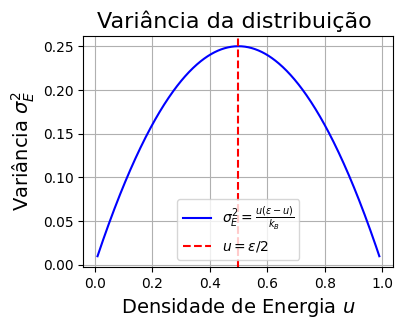

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de epsilon e k_B
epsilon_value = 1.0
k_B_value = 1.0

# Definindo o intervalo para u
u_values = np.linspace(0.01, epsilon_value - 0.01, 500)

# Calculando a variância sigma^2_E
variance_values = (u_values * (epsilon_value - u_values)) / k_B_value

# Criando o gráfico
plt.figure(figsize=(4, 3))
plt.plot(u_values, variance_values, label=r'$\sigma^2_E = \frac{u(\epsilon - u)}{k_B}$', color='blue')
plt.xlabel(r'Densidade de Energia $u$', fontsize=14)
plt.ylabel(r'Variância $\sigma^2_E$', fontsize=14)
plt.title('Variância da distribuição ', fontsize=16)
plt.axvline(epsilon_value/2, color='red', linestyle='--', label=r'$u = \epsilon/2$')
plt.legend()
plt.grid(True)
plt.show()


## Exemplo do prof. Zamora


### Regras associadas ao modelo

1. Cada partícula (ou ovo) pode ter um de três valores de energia possíveis: E1 = 4, E2 = -51, ou E3 = 37.
2. A energia total de um sistema de partículas é a soma das energias de todas as partículas.
3. A distribuição das partículas entre os diferentes níveis de energia pode ser representada por N1, N2 e N3 , onde N1 + N2 + N3 = N, sendo N o número total de partículas.
4. Para encontrar as configurações possíveis de distribuição, resolvem-se sistemas de equações envolvendo a energia total e o número total de partículas.
5. O número de microestados (configurações possíveis) para um macroestado específico é calculado usando combinações, representando a distribuição das partículas nos diferentes níveis de energia.
6. Macroestados com maior número de microestados são mais prováveis, conforme a análise estatística.

### Macroestados (configurações possíveis)

In [ ]:
import sympy as sp

# Definindo as variáveis
n1, n2, n3 = sp.symbols('n1 n2 n3')

# Valores dados
E1 = 4
E2 = -51
E3 = 37
N = 14
E_total = 100

# Sistema de equações para n1 = 2
eq1_n1_2 = sp.Eq(2 + n2 + n3, N)
eq2_n1_2 = sp.Eq(2 * E1 + n2 * E2 + n3 * E3, E_total)

# Resolvendo o sistema para n1 = 2
solution_n1_2 = sp.solve((eq1_n1_2, eq2_n1_2), (n2, n3))

# Sistema de equações para n1 = 10
eq1_n1_10 = sp.Eq(10 + n2 + n3, N)
eq2_n1_10 = sp.Eq(10 * E1 + n2 * E2 + n3 * E3, E_total)

# Resolvendo o sistema para n1 = 10
solution_n1_10 = sp.solve((eq1_n1_10, eq2_n1_10), (n2, n3))

solution_n1_2, solution_n1_10


({n2: 4, n3: 8}, {n2: 1, n3: 3})

### Microestados acessíveis ao sistema

In [ ]:
import math

# Função para calcular o número de combinações
def combinacoes(n, k):
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

# Macroestado 1: n1=2, n2=4, n3=8
n1_1, n2_1, n3_1 = 2, 4, 8
total_1 = combinacoes(14, 2) * combinacoes(12, 4) * combinacoes(8, 8)

# Macroestado 2: n1=10, n2=1, n3=3
n1_2, n2_2, n3_2 = 10, 1, 3
total_2 = combinacoes(14, 10) * combinacoes(4, 1) * combinacoes(3, 3)

total_1, total_2


(45045, 4004)

### Entropia vs energia

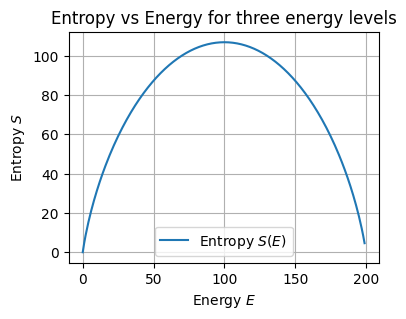

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

# Constants
k_B = 1  # Boltzmann constant (set to 1 for simplicity)
N = 100  # Total number of particles
epsilon = 1  # Energy of the first excited state (unit energy)

# Function to calculate the multiplicity for three energy levels
def multiplicity(N, E, epsilon):
    omega = 0
    # Loop over possible values of N1 (number of particles with energy epsilon)
    for N1 in range(N + 1):
        N2 = (E - N1 * epsilon) / (2 * epsilon)  # Solve for N2
        if N2.is_integer() and 0 <= N2 <= N:  # N2 must be an integer and within valid range
            N2 = int(N2)
            N0 = N - N1 - N2  # Solve for N0
            if N0 >= 0:
                omega += factorial(N) / (factorial(N0) * factorial(N1) * factorial(N2))
    return omega

# Energy range
E_values = np.arange(0, 2 * epsilon * N, epsilon)

# Calculate entropy S as a function of energy E
S_values = []
for E in E_values:
    Omega = multiplicity(N, E, epsilon)
    S = k_B * np.log(Omega) if Omega > 0 else 0
    S_values.append(S)

# Plot the results
plt.figure(figsize=(4, 3))
plt.plot(E_values, S_values, label='Entropy $S(E)$')
plt.xlabel('Energy $E$')
plt.ylabel('Entropy $S$')
plt.title('Entropy vs Energy for three energy levels')
plt.legend()
plt.grid(True)
plt.show()


###Entropia vs nº de partículas

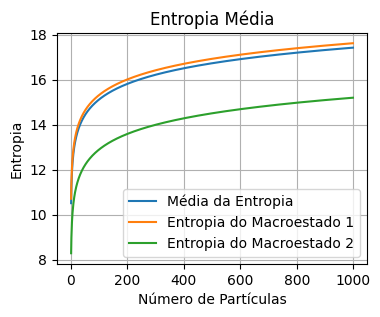

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definindo as constantes do problema
S1 = 10.7154173  # Entropia do macroestado 1
S2 = 8.29504914  # Entropia do macroestado 2
Ω1 = 45045
Ω2 = 4004

# Número de partículas variando de 1 a 1000
num_particles = np.arange(1, 1000)

# Calculando Ω1 e Ω2 como funções do número de partículas
Ω1_particles = Ω1 * num_particles
Ω2_particles = Ω2 * num_particles

# Calculando as entropias como funções do número de partículas
S1_particles = np.log(Ω1_particles)
S2_particles = np.log(Ω2_particles)

# Média da entropia
mean_entropy_particles = (Ω1_particles * S1_particles + Ω2_particles * S2_particles) / (Ω1_particles + Ω2_particles)

# Variância da entropia
variance_entropy_particles = ((Ω1_particles * (S1_particles - mean_entropy_particles)**2 +
                              Ω2_particles * (S2_particles - mean_entropy_particles)**2) /
                              (Ω1_particles + Ω2_particles))

# Gráfico da entropia média em função do número de partículas
plt.figure(figsize=(4, 3))

# Entropia média
plt.plot(num_particles, mean_entropy_particles, label='Média da Entropia')

# Entropia do macroestado 1
plt.plot(num_particles, S1_particles, label='Entropia do Macroestado 1')

# Entropia do macroestado 2
plt.plot(num_particles, S2_particles, label='Entropia do Macroestado 2')

plt.xlabel('Número de Partículas')
plt.ylabel('Entropia')
plt.title('Entropia Média')
plt.legend()
plt.grid(True)
plt.show()

###Eq. (59), pág. 130 do Salinas

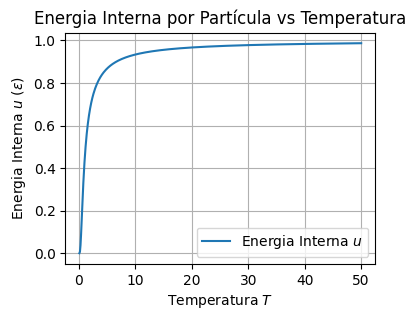

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
kB = 1.0  # Constante de Boltzmann em unidades arbitrárias
epsilon = 1.0  # Energia epsilon também em unidades arbitrárias

# Função para a energia interna u (adaptada para 3 níveis de energia)
def energia_interna(beta, epsilon):
    Z = 1 + np.exp(-beta * epsilon) + np.exp(-beta * 2 * epsilon)
    u = (epsilon * np.exp(-beta * epsilon) + 2 * epsilon * np.exp(-beta * 2 * epsilon)) / Z
    return u

# Temperaturas variando em uma faixa de T_min a T_max
T_real = np.linspace(0.1, 50, 500)  # Temperatura em uma escala direta
beta_real = 1 / T_real  # Assumindo que kB = 1 para simplificação das unidades

# Calculando a energia interna com T real
u_real = energia_interna(beta_real, epsilon)

# Plotando o gráfico da energia interna em função de T (sem normalização)
plt.figure(figsize=(4,3))
plt.plot(T_real, u_real, label='Energia Interna $u$')
plt.xlabel('Temperatura $T$')
plt.ylabel('Energia Interna $u$ ($\epsilon$)')
plt.title('Energia Interna por Partícula vs Temperatura')
plt.grid(True)
plt.legend()
plt.show()


###Distribuição de probabilidades

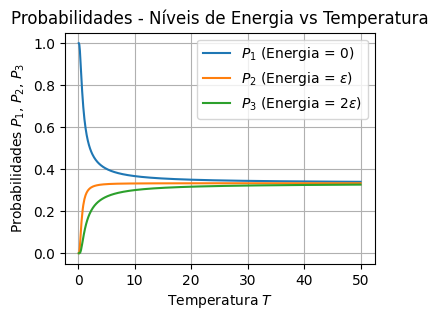

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
kB = 1.0  # Constante de Boltzmann em unidades arbitrárias
epsilon = 1.0  # Energia epsilon também em unidades arbitrárias

# Função para a energia interna u (adaptada para 3 níveis de energia)
def energia_interna(beta, epsilon):
    Z = 1 + np.exp(-beta * epsilon) + np.exp(-beta * 2 * epsilon)
    u = (epsilon * np.exp(-beta * epsilon) + 2 * epsilon * np.exp(-beta * 2 * epsilon)) / Z
    return u

# Função para as probabilidades no sistema de três níveis de energia
def probabilidades(beta, epsilon):
    Z3 = 1 + np.exp(-beta * epsilon) + np.exp(-beta * 2 * epsilon)
    P1 = 1 / Z3
    P2 = np.exp(-beta * epsilon) / Z3
    P3 = np.exp(-beta * 2 * epsilon) / Z3
    return P1, P2, P3

# Temperaturas variando em uma faixa de T_min a T_max
T_real = np.linspace(0.1, 50, 500)  # Temperatura em uma escala direta
beta_real = 1 / T_real  # Assumindo que kB = 1 para simplificação das unidades

# Calculando as probabilidades para diferentes valores de beta
P1, P2, P3 = probabilidades(beta_real, epsilon)

# Plotando as probabilidades em função de T
plt.figure(figsize=(4,3))
plt.plot(T_real, P1, label='$P_1$ (Energia = 0)')
plt.plot(T_real, P2, label='$P_2$ (Energia = $\epsilon$)')
plt.plot(T_real, P3, label='$P_3$ (Energia = $2\epsilon$)')
plt.xlabel('Temperatura $T$')
plt.ylabel('Probabilidades $P_1$, $P_2$, $P_3$')
plt.title('Probabilidades - Níveis de Energia vs Temperatura')
plt.grid(True)
plt.legend()
plt.show()


### Modelo de entropiômetro

Fonte:


*   http://qnesc.sbq.org.br/online/artigos/06-CCD-71-17.pdf



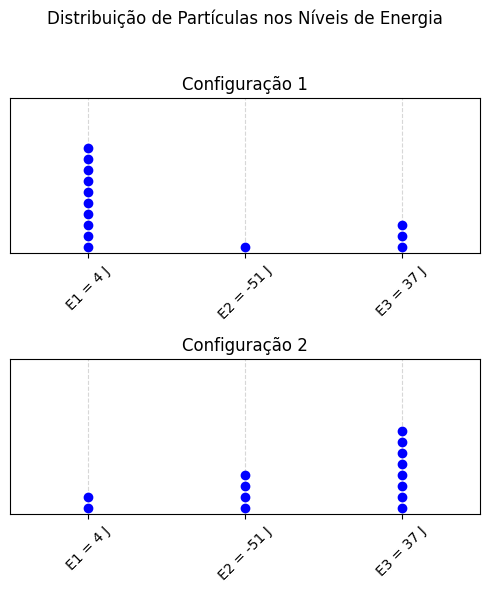

In [ ]:
import matplotlib.pyplot as plt
import itertools

def calcular_microestados(n_niveis, energias, n_moleculas):
    # Gerar todos os possíveis microestados
    niveis = list(range(n_niveis))
    microestados = list(itertools.combinations_with_replacement(niveis, n_moleculas))

    microestados_validos = []

    for microestado in microestados:
        energia_total = sum(energias[n] for n in microestado)
        if energia_total == 100:  # Ajuste o valor desejado
            microestados_validos.append(microestado)

    return microestados_validos

def plotar_microestados(microestados, energias):
    fig, axs = plt.subplots(len(microestados), 1, figsize=(5, len(microestados) * 3))
    fig.suptitle('Distribuição de Partículas nos Níveis de Energia')

    if len(microestados) == 1:
        axs = [axs]  # Garantir que axs seja sempre uma lista

    for i, microestado in enumerate(microestados):
        for nivel in set(microestado):
            count = microestado.count(nivel)
            axs[i].plot([nivel]*count, range(count), 'o', color='blue')

        axs[i].set_yticks([])
        axs[i].set_xticks(range(len(energias)))
        axs[i].set_xticklabels([f'E{j+1} = {e} J' for j, e in enumerate(energias)], rotation=45)
        axs[i].set_xlim(-0.5, len(energias) - 0.5)
        axs[i].set_ylim(-0.5, max(len(microestado) for microestado in microestados) - 0.5)
        axs[i].set_title(f'Configuração {i + 1}')
        axs[i].grid(True, axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Configurações iniciais
n_niveis = 3
energias = [4, -51, 37]  # Energia associada a cada nível
n_moleculas = 14

# Calcular microestados válidos
microestados_validos = calcular_microestados(n_niveis, energias, n_moleculas)

# Plotar microestados
plotar_microestados(microestados_validos, energias)


## Sistema de 2 niveis: aprofudamento


Ver cap.9 (página 149) dessa Ref.
http://43.143.80.206:8548/static/books/Books_CFD20230418/A05_ThermalPhysicsTutorialswithPythonSimulations2023.pdf



Reproduzir:
*   Figura 9.1 até Figura 9.5



###Figura 9.1

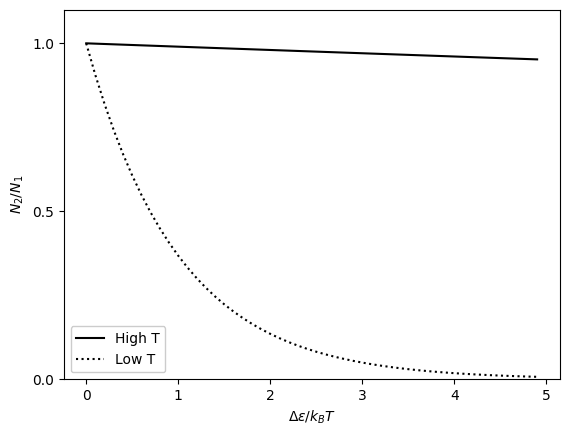

In [ ]:
 # Code Block 9.1
 # Comparing the occupancy between two states.
 import matplotlib.pyplot as plt
 import numpy as np
 kT_hi = 100
 kT_lo = 1
 e = np.arange(0,5,0.1)
 plt.plot(e,np.exp(-e/kT_hi),color='k',linestyle='solid')
 plt.plot(e,np.exp(-e/kT_lo),color='k',linestyle='dotted')
 plt.legend(('High T','Low T'),framealpha=1)
 plt.ylabel('$N_2 / N_1$')
 plt.xlabel('$\Delta \epsilon / k_B T$')
 plt.ylim((0,1.1))
 plt.yticks(ticks=(0,0.5,1))
 plt.savefig('fig_ch9_ratio_vs_epsilon.eps')
 plt.show()

###Figura 9.2

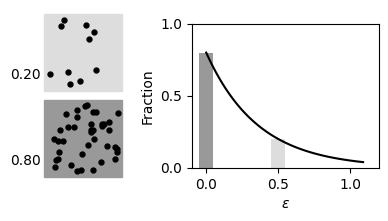

In [ ]:
# Code Block 9.2
import matplotlib.pyplot as plt # Fixed: Removed extra leading whitespace
import numpy as np
def sketch_distrib_2states (n,de=1,kT=None,xmax=1.1,figsize=(4,5)):
    # Makes a cartoon of occupancy plot.
    gridspec = {'width_ratios':[1,2*xmax]}
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=figsize,
    gridspec_kw=gridspec)
    # The basic logic of the following sketch is the same
    # as sketch_occupancy() from an ealier chapter,
    # but it also includes an extra bar graph.
    # Define the size of boxes
    marg = 0.05 # Size of margin
    h = 1.0-2*marg
    w = 1.0-2*marg
    xbox = np.array([marg,marg+w,marg+w,marg])
    ybox = np.array([marg,marg,marg+h,marg+h])
    colors = ['#999999','#DDDDDD'] # darker, lighter gray
    n = np.array(n)
    for i in range(2):
        ax1.fill(xbox,ybox+i,color=colors[i])
        x = (np.random.uniform(size=n[i])-0.5)*w*0.9+0.5
        y = (np.random.uniform(size=n[i])-0.5)*h*0.9+0.5+i
        ax1.scatter(x,y,marker='.',color='k',s=50,zorder=2.5)
        # Display the fraction to the left of each box.
        ax1.text(-0.35,i+0.2,'%3.2f'%(n[i]/np.sum(n)))
    ax1.set_ylim(0,2)
    ax1.set_yticks([])
    ax1.set_xticks([])
    ax1.set_aspect('equal')
    ax1.axis('off')
    # If kT is not specified as an optional input argument,
    # calculate equilibrium kT given n[0] and n[1].
    if kT==None:
        kT =-de/np.log(n[1]/n[0])
    f = n/np.sum(n) # fraction of occupancy.
    e = np.array([0,de])
    for i in range(2):
        ax2.bar(e[i],f[i],width=0.1,color=colors[i])
    Z = 1 + np.exp(-de/kT) # Partition function
    de_range = np.arange(0,xmax,0.01) # energy difference
    boltzmann_dist = np.exp(-de_range/kT)/Z
    ax2.plot(de_range,boltzmann_dist,color='black')
    ax2.set_xlabel('$\epsilon$') # Fixed: Corrected the string literal
    ax2.set_xticks(np.arange(0,xmax+0.1,0.5))
    ax2.set_xlim((-0.1,xmax+0.1))
    ax2.set_ylim((0,1))
    ax2.set_yticks((0,0.5,1))
    ax2.set_ylabel('Fraction')
    ax2.set_aspect('equal')
    plt.tight_layout()
    return kT

n = [40,10]
de = 0.5
sketch_distrib_2states(n,de=de,figsize=(4,5))
plt.savefig('fig_ch9_sketch_distrib_2states_demo.eps', bbox_inches='tight')
plt.show()

### Figura 9.3

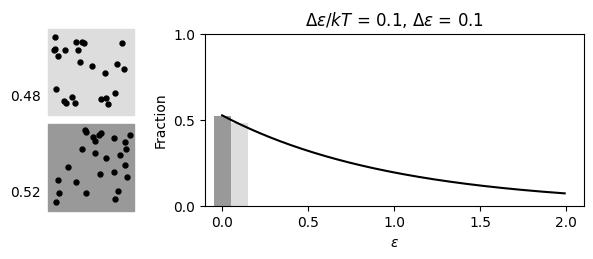

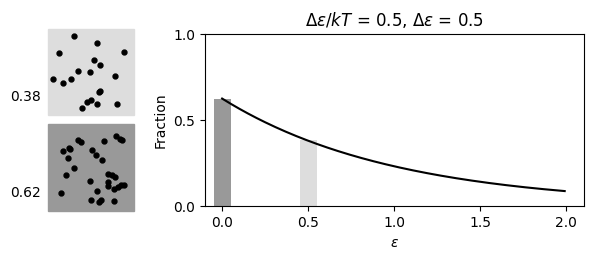

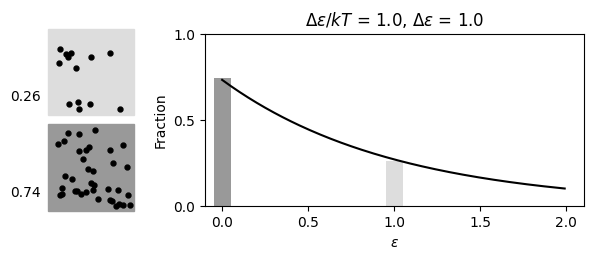

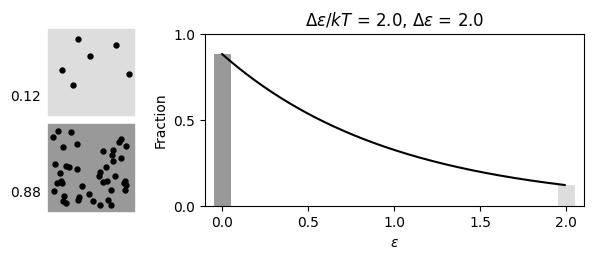

In [ ]:
 # Code Block 9.3
 # Sketch a series of distribution plots for a range of energy gaps.
 N_total = 50
 kT = 1
 de_range = np.array([0.1,0.5,1,2])
 for i, de in enumerate(de_range):
  r = np.exp(-de/kT)
  N1 = np.round(N_total/(1+r))
  N2 = np.round(N_total-N1)
  n = np.array([N1,N2],dtype='int')
  sketch_distrib_2states (n,de=de,kT=kT,xmax=2,figsize=(6,8))
  str = '$\Delta \epsilon/kT$ = %2.1f, $\Delta \epsilon$ = %2.1f'
  plt.title(str%(de/kT,de))
  plt.savefig('fig_ch9_occupancy_fixed_T_%d.eps'%i, bbox_inches='tight')
  plt.show()

### Comentário figura 9.3 (Variação de ∆ε/kT):
∆ε/kT: Este parâmetro representa a razão entre a diferença de energia entre dois estados (∆ε) e a energia térmica média (kT). À medida que ∆ε/kT aumenta, a ocupação relativa do nível de energia mais baixo (N1) se torna maior em comparação com o nível mais alto (N2). Isso significa que, quanto maior a diferença de energia em relação à energia térmica, mais partículas ocupam o nível de energia mais baixo.
### Comportamento:
Aumentando ∆ε, o sistema se inclina mais para o estado de menor energia, ou seja, há uma maior concentração de partículas no nível mais baixo. Visualmente, isso é mostrado pela separação crescente entre as barras (representando N1 e N2) e pelo aumento da densidade de pontos no nível inferior.

### Figura 9.4

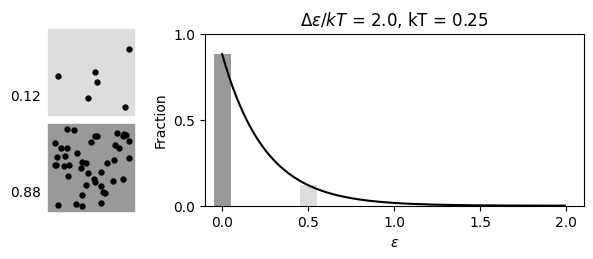

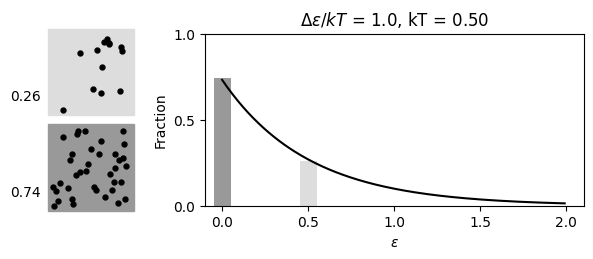

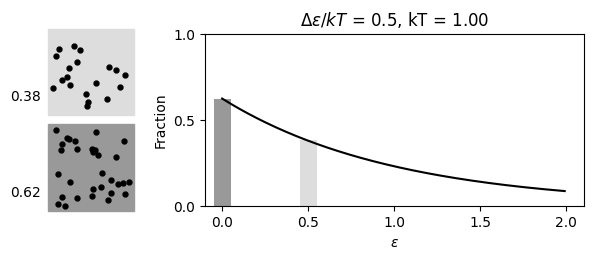

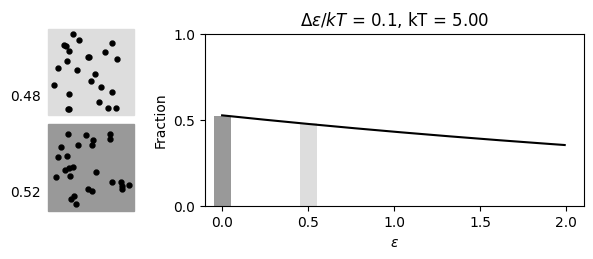

In [ ]:
# Code Block 9.4
# Sketch a series of distribution plots for different thermal energy.
N_total = 50
de = 0.5
kT_range = np.array([0.25, 0.5, 1, 5])
for i, kT in enumerate(kT_range):
    # Indented block for the for loop
    r = np.exp(-de / kT)
    N1 = np.round(N_total / (1 + r))
    N2 = np.round(N_total - N1)
    n = np.array([N1, N2], dtype='int')
    sketch_distrib_2states(n, de=de, kT=kT, xmax=2, figsize=(6, 8))
    str = '$\Delta \epsilon/kT$ = %2.1f, kT = %3.2f'
    plt.title(str % (de / kT, kT))
    plt.savefig('fig_ch9_occupancy_fixed_de_%d.eps' % i,
                bbox_inches='tight')
    plt.show()

### Figura 9.4 (Variação de kT com ∆ε fixo):
kT: Aqui, o parâmetro kT (energia térmica média) é variado enquanto a diferença de energia ∆ε permanece constante. À medida que kT aumenta, a diferença de energia entre os dois níveis (∆ε) torna-se menos relevante para a distribuição das partículas, e a ocupação entre os dois níveis se torna mais equilibrada.
### Comportamento:
Aumentando kT, a ocupação dos dois níveis de energia se aproxima, resultando em um número quase igual de partículas em ambos os níveis. Visualmente, isso é mostrado pela convergência das alturas das barras e pela menor distinção na densidade de partículas entre os dois níveis de energia.

###Figura 9.5

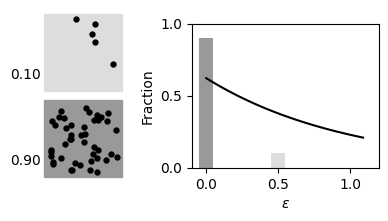

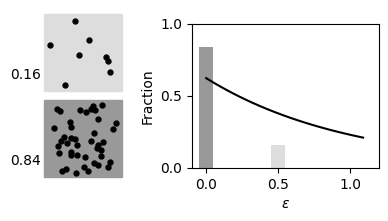

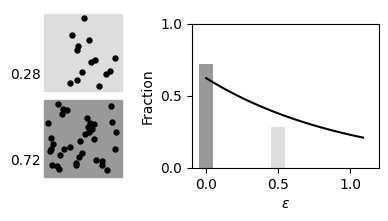

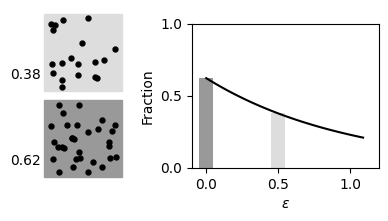

In [ ]:
# Code Block 9.5
# Sketch of transition toward equilibrium state.
N_total = 50 # Fixed: Removed extra leading whitespace
de = 0.5
kT = 1
r_range = np.array([0.1,0.2,0.4,0.6])
for i, r in enumerate(r_range):
    # Indented block for the for loop
    N1 = np.round(N_total/(1+r))
    N2 = np.round(N_total-N1)
    n = np.array([N1,N2],dtype='int')
    sketch_distrib_2states (n,de=de,kT=kT,figsize=(4,5))
    plt.savefig('fig_ch9_occupancy_dynamic_%d.eps'%i,
    bbox_inches='tight')
    plt.show()

### Significado do parâmetro r:
r = N2/N1: O parâmetro r representa a razão entre o número de partículas no nível de energia mais alto (N2) e o número de partículas no nível mais baixo (N1).
Quando r é pequeno (ou seja, muito menor que 1), a maioria das partículas está no nível de energia mais baixo (N1).
Quando r se aproxima de 1, as ocupações dos dois níveis se tornam comparáveis.

###Entropia (figs. 9.3 e 9.4)

<ipython-input-2-7e701b25f161>:16: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Omega = np.math.factorial(N_total) / (np.math.factorial(N1) * np.math.factorial(N2))


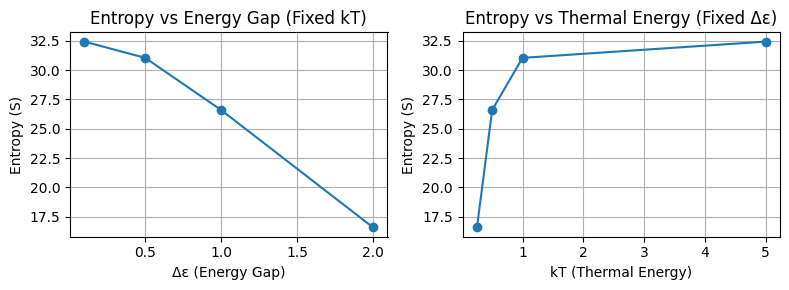

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants and parameters
N_total = 50  # Total number of particles
kB = 1  # Boltzmann constant in arbitrary units
kT = 1  # Default thermal energy for Figure 9.3
de_range = np.array([0.1, 0.5, 1, 2])  # Energy gaps for Figure 9.3
kT_range = np.array([0.25, 0.5, 1, 5])  # Thermal energy range for Figure 9.4
de_fixed = 0.5  # Fixed energy gap for Figure 9.4

def boltzmann_entropy(N1, N2):
    """Calculate Boltzmann entropy given N1 and N2."""
    if N1 == 0 or N2 == 0:  # Avoid log(0)
        return 0
    Omega = np.math.factorial(N_total) / (np.math.factorial(N1) * np.math.factorial(N2))
    return kB * np.log(Omega)

# Entropy plots for Figure 9.3 (varying Δε, fixed kT)
entropy_values_93 = []
for de in de_range:
    r = np.exp(-de / kT)
    N1 = int(np.round(N_total / (1 + r)))
    N2 = N_total - N1
    S = boltzmann_entropy(N1, N2)
    entropy_values_93.append(S)

# Entropy plots for Figure 9.4 (varying kT, fixed Δε)
entropy_values_94 = []
for kT_var in kT_range:
    r = np.exp(-de_fixed / kT_var)
    N1 = int(np.round(N_total / (1 + r)))
    N2 = N_total - N1
    S = boltzmann_entropy(N1, N2)
    entropy_values_94.append(S)

# Plotting
plt.figure(figsize=(8, 3))

# Plot for Figure 9.3
plt.subplot(1, 2, 1)
plt.plot(de_range, entropy_values_93, marker='o')
plt.xlabel('Δε (Energy Gap)')
plt.ylabel('Entropy (S)')
plt.title('Entropy vs Energy Gap (Fixed kT)')
plt.grid(True)

# Plot for Figure 9.4
plt.subplot(1, 2, 2)
plt.plot(kT_range, entropy_values_94, marker='o')
plt.xlabel('kT (Thermal Energy)')
plt.ylabel('Entropy (S)')
plt.title('Entropy vs Thermal Energy (Fixed Δε)')
plt.grid(True)

# Display the plots
plt.tight_layout()
plt.show()


## Gas de Ehrenfest

O modelo do Gás de Ehrenfest descreve um sistema com as seguintes regras:

1. O sistema consiste em dois compartimentos (caixas ou urnas), designados como Compartimento 1 e Compartimento 2.

2. Existem N partículas no total, numeradas de 1 a N.

3. Inicialmente, algumas dessas partículas estão localizadas no Compartimento 1, enquanto o restante está no Compartimento 2.

4. Em cada unidade de tempo, uma partícula é escolhida aleatoriamente  e transferida para o compartimento oposto.

5. Este procedimento é repetido sequencialmente ao longo do tempo.

Simulação concluída com sucesso!
GIF criado: modelo_ehrenfest.gif
Número total de partículas: 120
Estado inicial: n_A = 100
Estado final: n_A = 62 e n_B = 58


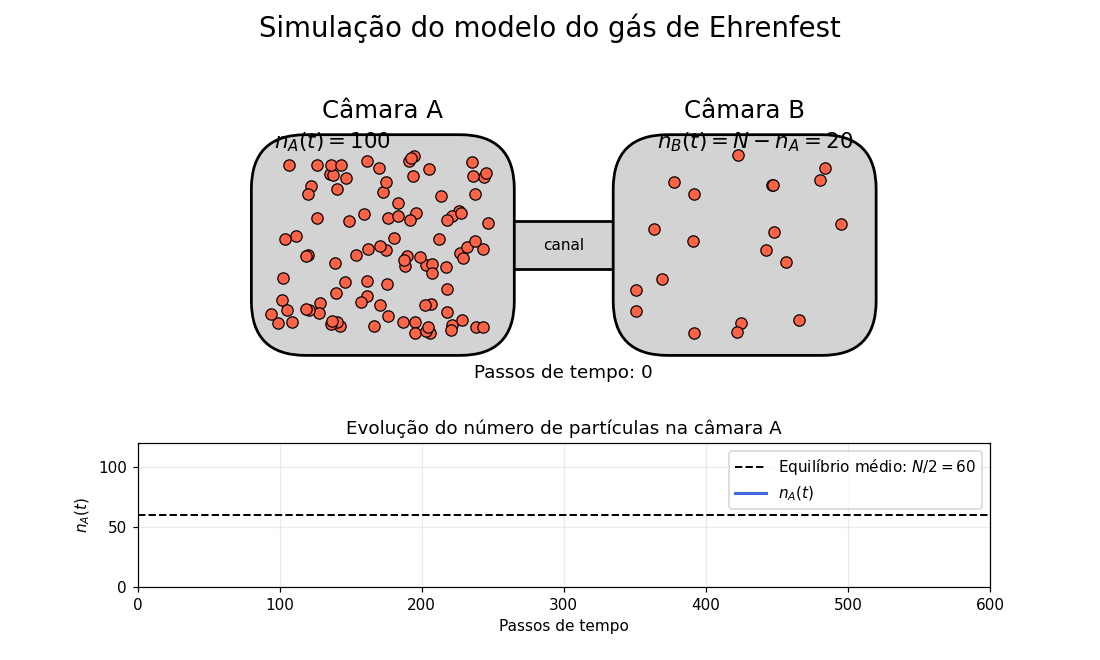

In [9]:
# ============================================================
# SIMULAÇÃO ANIMADA DO MODELO DO GÁS DE EHRENNFEST
# Código pronto para Google Colab
# ============================================================

!pip -q install pillow

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch, Rectangle
from IPython.display import Image, display
from google.colab import files


# ============================================================
# PARÂMETROS DA SIMULAÇÃO
# ============================================================

N = 120                    # número total de partículas
N_A_INICIAL = 100          # partículas inicialmente na câmara A
NUMERO_DE_PASSOS = 600     # número de passos de Monte Carlo

NUMERO_DE_FRAMES = 120     # quantidade de quadros do GIF
INTERVALO_MS = 80          # intervalo entre os quadros
SEMENTE = 15               # semente aleatória

NOME_DO_GIF = "modelo_ehrenfest.gif"


# ============================================================
# VALIDAÇÃO DOS PARÂMETROS
# ============================================================

if N <= 0:
    raise ValueError("N deve ser maior que zero.")

if not 0 <= N_A_INICIAL <= N:
    raise ValueError("N_A_INICIAL deve estar entre 0 e N.")

if NUMERO_DE_PASSOS <= 0:
    raise ValueError("NUMERO_DE_PASSOS deve ser maior que zero.")


# ============================================================
# SIMULAÇÃO DO MODELO DE EHRENFEST
# ============================================================

rng = np.random.default_rng(SEMENTE)

# True representa uma partícula na câmara A.
# False representa uma partícula na câmara B.
particulas_na_camara_A = np.zeros(N, dtype=bool)

particulas_na_camara_A[:N_A_INICIAL] = True

# Embaralha os índices das partículas
rng.shuffle(particulas_na_camara_A)

# Armazena o estado do sistema a cada passo
estados = [particulas_na_camara_A.copy()]

# Armazena a quantidade de partículas na câmara A
historico_n_A = [int(particulas_na_camara_A.sum())]


for passo in range(NUMERO_DE_PASSOS):

    # Escolhe aleatoriamente uma das partículas
    indice_escolhido = int(rng.integers(0, N))

    # A partícula escolhida atravessa para a outra câmara
    particulas_na_camara_A[indice_escolhido] = (
        not particulas_na_camara_A[indice_escolhido]
    )

    # Salva o novo estado
    estados.append(particulas_na_camara_A.copy())

    # Registra a quantidade de partículas na câmara A
    historico_n_A.append(
        int(particulas_na_camara_A.sum())
    )


historico_n_A = np.asarray(historico_n_A)


# ============================================================
# FUNÇÃO PARA GERAR AS POSIÇÕES DAS PARTÍCULAS
# ============================================================

def gerar_coordenadas(quantidade, caixa, rng_local, margem=0.25):
    """
    Gera posições aleatórias dentro de uma região retangular.

    caixa = (posição_x, posição_y, largura, altura)
    """

    x, y, largura, altura = caixa

    coordenadas_x = rng_local.uniform(
        x + margem,
        x + largura - margem,
        quantidade
    )

    coordenadas_y = rng_local.uniform(
        y + margem,
        y + altura - margem,
        quantidade
    )

    return coordenadas_x, coordenadas_y


# ============================================================
# FUNÇÃO PARA DESENHAR AS DUAS CÂMARAS
# ============================================================

def desenhar_recipiente(ax):

    # Câmara A
    camara_A = FancyBboxPatch(
        (0.4, 1.2),
        4.2,
        3.5,
        boxstyle="round,pad=0.08,rounding_size=0.9",
        linewidth=1.8,
        facecolor="lightgray",
        edgecolor="black",
        zorder=1
    )

    # Câmara B
    camara_B = FancyBboxPatch(
        (6.4, 1.2),
        4.2,
        3.5,
        boxstyle="round,pad=0.08,rounding_size=0.9",
        linewidth=1.8,
        facecolor="lightgray",
        edgecolor="black",
        zorder=1
    )

    # Canal de ligação
    canal = Rectangle(
        (4.45, 2.55),
        2.1,
        0.8,
        linewidth=1.8,
        facecolor="lightgray",
        edgecolor="black",
        zorder=0
    )

    ax.add_patch(canal)
    ax.add_patch(camara_A)
    ax.add_patch(camara_B)

    ax.text(
        2.5,
        5.05,
        "Câmara A",
        fontsize=16,
        ha="center"
    )

    ax.text(
        8.5,
        5.05,
        "Câmara B",
        fontsize=16,
        ha="center"
    )

    ax.text(
        5.5,
        2.95,
        "canal",
        fontsize=10,
        ha="center",
        va="center"
    )

    ax.set_xlim(0, 11)
    ax.set_ylim(0.6, 5.7)

    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================
# SELEÇÃO DOS PASSOS QUE APARECERÃO NO GIF
# ============================================================

quantidade_de_frames = min(
    NUMERO_DE_FRAMES,
    len(estados)
)

passos_dos_frames = np.unique(
    np.linspace(
        0,
        len(estados) - 1,
        quantidade_de_frames,
        dtype=int
    )
)


# ============================================================
# CRIAÇÃO DA FIGURA
# ============================================================

figura = plt.figure(figsize=(10, 6))

grade = figura.add_gridspec(
    2,
    1,
    height_ratios=[3.2, 1.5],
    hspace=0.25
)

ax_gas = figura.add_subplot(grade[0])
ax_grafico = figura.add_subplot(grade[1])

desenhar_recipiente(ax_gas)


# Objetos que representam as partículas
particulas_A = ax_gas.scatter(
    [],
    [],
    s=55,
    facecolor="tomato",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

particulas_B = ax_gas.scatter(
    [],
    [],
    s=55,
    facecolor="tomato",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)


# Textos informativos
texto_A = ax_gas.text(
    0.7,
    4.55,
    "",
    fontsize=14
)

texto_B = ax_gas.text(
    10.3,
    4.55,
    "",
    fontsize=14,
    ha="right"
)

texto_passo = ax_gas.text(
    5.5,
    0.75,
    "",
    fontsize=12,
    ha="center"
)


# ============================================================
# CONFIGURAÇÃO DO GRÁFICO TEMPORAL
# ============================================================

ax_grafico.set_xlim(
    0,
    NUMERO_DE_PASSOS
)

ax_grafico.set_ylim(
    0,
    N
)

ax_grafico.set_xlabel(
    "Passos de tempo"
)

ax_grafico.set_ylabel(
    r"$n_A(t)$"
)

ax_grafico.set_title(
    "Evolução do número de partículas na câmara A"
)

# Linha correspondente ao valor médio de equilíbrio
ax_grafico.axhline(
    N / 2,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label=rf"Equilíbrio médio: $N/2={N/2:.0f}$"
)

linha_historico, = ax_grafico.plot(
    [],
    [],
    color="royalblue",
    linewidth=2,
    label=r"$n_A(t)$"
)

ax_grafico.grid(
    alpha=0.25
)

ax_grafico.legend(
    loc="upper right"
)

figura.suptitle(
    "Simulação do modelo do gás de Ehrenfest",
    fontsize=18
)


# ============================================================
# FUNÇÃO DE ATUALIZAÇÃO DA ANIMAÇÃO
# ============================================================

def atualizar_animacao(numero_do_frame):

    passo_atual = int(
        passos_dos_frames[numero_do_frame]
    )

    estado_atual = estados[passo_atual]

    n_A = int(
        estado_atual.sum()
    )

    n_B = N - n_A

    # Semente própria de cada quadro
    rng_frame = np.random.default_rng(
        SEMENTE + 10000 + passo_atual
    )

    # Coordenadas das partículas da câmara A
    x_A, y_A = gerar_coordenadas(
        n_A,
        caixa=(0.4, 1.2, 4.2, 3.5),
        rng_local=rng_frame
    )

    # Coordenadas das partículas da câmara B
    x_B, y_B = gerar_coordenadas(
        n_B,
        caixa=(6.4, 1.2, 4.2, 3.5),
        rng_local=rng_frame
    )

    if n_A > 0:
        particulas_A.set_offsets(
            np.column_stack((x_A, y_A))
        )
    else:
        particulas_A.set_offsets(
            np.empty((0, 2))
        )

    if n_B > 0:
        particulas_B.set_offsets(
            np.column_stack((x_B, y_B))
        )
    else:
        particulas_B.set_offsets(
            np.empty((0, 2))
        )

    texto_A.set_text(
        rf"$n_A(t)={n_A}$"
    )

    texto_B.set_text(
        rf"$n_B(t)=N-n_A={n_B}$"
    )

    texto_passo.set_text(
        f"Passos de tempo: {passo_atual}"
    )

    # Atualização do gráfico
    eixo_x = np.arange(
        passo_atual + 1
    )

    eixo_y = historico_n_A[
        :passo_atual + 1
    ]

    linha_historico.set_data(
        eixo_x,
        eixo_y
    )

    return (
        particulas_A,
        particulas_B,
        texto_A,
        texto_B,
        texto_passo,
        linha_historico
    )


# ============================================================
# CRIAÇÃO DA ANIMAÇÃO
# ============================================================

animacao = FuncAnimation(
    figura,
    atualizar_animacao,
    frames=len(passos_dos_frames),
    interval=INTERVALO_MS,
    blit=False,
    repeat=True
)


# ============================================================
# SALVAR COMO GIF
# ============================================================

quadros_por_segundo = max(
    4,
    int(1000 / INTERVALO_MS)
)

animacao.save(
    NOME_DO_GIF,
    writer=PillowWriter(
        fps=quadros_por_segundo
    ),
    dpi=110
)

plt.close(figura)


# ============================================================
# RESULTADOS
# ============================================================

n_A_final = historico_n_A[-1]
n_B_final = N - n_A_final

print("Simulação concluída com sucesso!")
print(f"GIF criado: {NOME_DO_GIF}")
print(f"Número total de partículas: {N}")
print(f"Estado inicial: n_A = {N_A_INICIAL}")
print(f"Estado final: n_A = {n_A_final} e n_B = {n_B_final}")


# ============================================================
# EXIBIR O GIF NO GOOGLE COLAB
# ============================================================

display(
    Image(
        filename=NOME_DO_GIF
    )
)



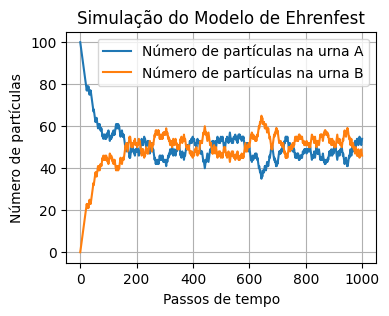

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo os parâmetros do modelo de Ehrenfest
N = 100  # Número total de partículas
steps = 1000  # Número de passos de tempo
initial_A = N  # Inicialmente todas as partículas estão na urna A

# Inicializando o número de partículas na urna A e B
particles_A = initial_A
particles_B = N - initial_A

# Listas para armazenar o número de partículas em A e B ao longo do tempo
particles_A_over_time = [particles_A]
particles_B_over_time = [particles_B]

# Simulação do modelo de Ehrenfest
for _ in range(steps):
    if np.random.rand() < particles_A / N:
        particles_A -= 1
        particles_B += 1
    else:
        particles_A += 1
        particles_B -= 1
    particles_A_over_time.append(particles_A)
    particles_B_over_time.append(particles_B)

# Plotando os resultados
plt.figure(figsize=(4, 3))
plt.plot(particles_A_over_time, label="Número de partículas na urna A")
plt.plot(particles_B_over_time, label="Número de partículas na urna B")
plt.xlabel("Passos de tempo")
plt.ylabel("Número de partículas")
plt.title("Simulação do Modelo de Ehrenfest")
plt.legend()
plt.grid(True)
plt.show()


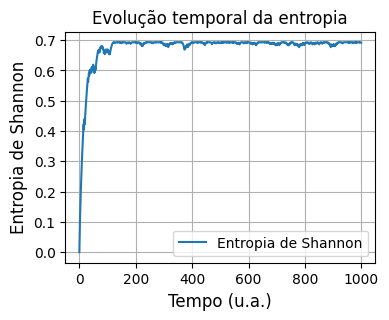

In [ ]:
# Importar bibliotecas necessárias
import numpy as np
import random as rd
import matplotlib.pyplot as plt

# Funções existentes no notebook
def ocorrencias(vec, x):
    return float(sum(vec==x))

def inicializacao(N, ne):
    bolas0 = np.zeros(ne, dtype=int)
    bolas1 = np.ones(N-ne, dtype=int)
    urna_inicial = np.concatenate((bolas0, bolas1), axis=None)
    return urna_inicial

def transferenciaDeUmabola(vetor_urna):
    numeroBolas = len(vetor_urna)
    sorteada = rd.randint(0, numeroBolas-1)
    vetor_urna[sorteada] = 1 - vetor_urna[sorteada]
    return vetor_urna

# Função para calcular a entropia de Shannon
def shannon_entropy(vetor_urna):
    p_0 = ocorrencias(vetor_urna, 0) / len(vetor_urna)
    p_1 = ocorrencias(vetor_urna, 1) / len(vetor_urna)
    if p_0 > 0 and p_1 > 0:
        return -p_0 * np.log(p_0) - p_1 * np.log(p_1)
    else:
        return 0

# Parâmetros
N  = 100
ne = N
tf = 10 * N

# Inicialização
bolaNaUrna = inicializacao(N, ne)

# Vetores para guardar resultados
vec_ne = [ocorrencias(bolaNaUrna, 0)]
vec_nd = [ocorrencias(bolaNaUrna, 1)]
vec_eq = [N / 2]
vec_entropy = [shannon_entropy(bolaNaUrna)]

# Transferência de bolas durante tf+1 instantes
for t in range(1, tf):
    bolaNaUrna = transferenciaDeUmabola(bolaNaUrna)
    vec_ne.append(ocorrencias(bolaNaUrna, 0))
    vec_nd.append(ocorrencias(bolaNaUrna, 1))
    vec_eq.append(N / 2)
    vec_entropy.append(shannon_entropy(bolaNaUrna))

# Plotando a evolução temporal da entropia de Shannon
plt.figure(figsize=(4, 3))
plt.plot(vec_entropy, label='Entropia de Shannon')
plt.ylabel('Entropia de Shannon', fontsize=12)
plt.xlabel('Tempo (u.a.)', fontsize=12)
plt.title('Evolução temporal da entropia', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## 6. Modelo de Ehrenfest-Adaptado

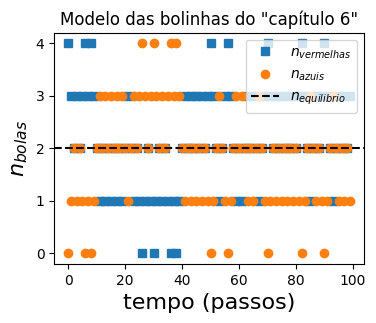

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número inicial de bolinhas vermelhas e azuis
N = 4  # Total de bolinhas (vermelhas + azuis)
n_red = N  # Inicialmente todas as bolinhas são vermelhas
n_blue = 0  # Inicialmente nenhuma bolinha azul

# Número de sorteios
steps = 100

# Vetores para armazenar o número de bolinhas vermelhas e azuis ao longo do tempo
vec_red = np.zeros(steps)
vec_blue = np.zeros(steps)

# Simulação do modelo de sorteio
for t in range(steps):
    vec_red[t] = n_red
    vec_blue[t] = n_blue
    if np.random.rand() < n_red / N:
        n_red -= 1
        n_blue += 1
    else:
        n_red += 1
        n_blue -= 1

# Plotando os resultados
plt.figure(figsize=(4, 3))
plt.plot(vec_red, 's', label='$n_{vermelhas}$')
plt.plot(vec_blue, 'o', label='$n_{azuis}$')
plt.ylabel('$n_{bolas}$', fontsize=16)
plt.xlabel('tempo (passos)', fontsize=16)
plt.title('Modelo das bolinhas do "capítulo 6"')
plt.axhline(y=float(N)/2, color='k', linestyle='--', label='$n_{equilibrio}$')
plt.legend()


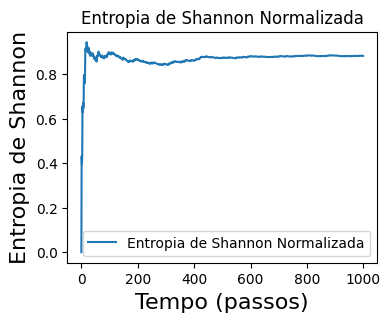

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número inicial de bolinhas vermelhas e azuis
N = 4  # Total de bolinhas (vermelhas + azuis)
n_red = N  # Inicialmente todas as bolinhas são vermelhas
n_blue = 0  # Inicialmente nenhuma bolinha azul

# Número de sorteios
steps = 1000  # Aumentar o número de sorteios para visualizar melhor as flutuações

# Vetores para armazenar o número de bolinhas vermelhas e azuis ao longo do tempo
vec_red = np.zeros(steps)
vec_blue = np.zeros(steps)

# Vetor para armazenar a entropia de Shannon ao longo do tempo
entropy_values = np.zeros(steps)

# Função para calcular a entropia de Shannon
def shannon_entropy(prob_dist):
    return -np.sum(prob_dist * np.log(prob_dist + (prob_dist == 0)))  # Evitar log(0)

# Valor máximo da entropia para normalização
max_entropy = np.log(N + 1)

# Simulação do modelo de sorteio
for t in range(steps):
    vec_red[t] = n_red
    vec_blue[t] = n_blue

    # Calcular a distribuição de probabilidade dos estados
    unique, counts = np.unique(vec_red[:t+1], return_counts=True)
    prob_dist = counts / (t + 1)

    # Calcular a entropia de Shannon e normalizar
    entropy_values[t] = shannon_entropy(prob_dist) / max_entropy

    # Realizar o sorteio
    if np.random.rand() < n_red / N:
        n_red -= 1
        n_blue += 1
    else:
        n_red += 1
        n_blue -= 1

# Plotando a evolução temporal da entropia de Shannon
plt.figure(figsize=(4, 3))
plt.plot(entropy_values, label='Entropia de Shannon Normalizada')
plt.ylabel('Entropia de Shannon', fontsize=16)
plt.xlabel('Tempo (passos)', fontsize=16)
plt.title('Entropia de Shannon Normalizada')
plt.legend()
plt.show()


###6.1. Modelo para o sorteio das bolinhas

In [ ]:
import numpy as np

# Definir a matriz de transição Q
Q = np.array([
    [0, 1/4, 0, 0, 0],
    [1, 0, 2/4, 0, 0],
    [0, 3/4, 0, 3/4, 0],
    [0, 0, 2/4, 0, 1],
    [0, 0, 0, 1/4, 0]
])

# Definir a matriz de transição Q_epsilon
epsilon = 1/36
Q_epsilon = np.array([
    [2*epsilon, 1/4 - epsilon, 0, 0, 0],
    [1 - 2*epsilon, 2*epsilon, 2/4 - epsilon, 0, 0],
    [0, 3/4 - epsilon, 2*epsilon, 3/4 - epsilon, 0],
    [0, 0, 2*1/4 - epsilon, 2*epsilon, 1 - 2*epsilon],
    [0, 0, 0, 1/4 - epsilon, 2*epsilon]
])

# Calcular Q_epsilon^2, Q_epsilon^3, e Q_epsilon^4
Q_epsilon_2 = np.linalg.matrix_power(Q_epsilon, 2)
Q_epsilon_3 = np.linalg.matrix_power(Q_epsilon, 3)
Q_epsilon_4 = np.linalg.matrix_power(Q_epsilon, 4)

# Resolver o sistema de equações para w
A = np.array([
    [1/18, 2/9, 0, 0, 0],
    [17/18, 1/18, 17/36, 0, 0],
    [0, 13/18, 1/18, 13/18, 0],
    [0, 0, 17/36, 1/18, 17/18],
    [0, 0, 0, 2/9, 1/18]
])
b = np.array([1/17, 1/4, 13/34, 1/4, 1/17])

w = np.linalg.solve(A, b)

# Calcular o tempo médio de retorno
w_0 = w[0]
m_0 = 1 / w_0

# Resultados
Q_epsilon, Q_epsilon_2, Q_epsilon_3, Q_epsilon_4, w, m_0


(array([[0.05555556, 0.22222222, 0.        , 0.        , 0.        ],
        [0.94444444, 0.05555556, 0.47222222, 0.        , 0.        ],
        [0.        , 0.72222222, 0.05555556, 0.72222222, 0.        ],
        [0.        , 0.        , 0.47222222, 0.05555556, 0.94444444],
        [0.        , 0.        , 0.        , 0.22222222, 0.05555556]]),
 array([[0.21296296, 0.02469136, 0.10493827, 0.        , 0.        ],
        [0.10493827, 0.55401235, 0.05246914, 0.34104938, 0.        ],
        [0.68209877, 0.08024691, 0.68518519, 0.08024691, 0.68209877],
        [0.        , 0.34104938, 0.05246914, 0.55401235, 0.10493827],
        [0.        , 0.        , 0.10493827, 0.02469136, 0.21296296]]),
 array([[0.03515089, 0.1244856 , 0.01748971, 0.07578875, 0.        ],
        [0.52906379, 0.09199246, 0.42558299, 0.05684156, 0.32210219],
        [0.11368313, 0.65089163, 0.1138546 , 0.65089163, 0.11368313],
        [0.32210219, 0.05684156, 0.42558299, 0.09199246, 0.52906379],
        [0.     



```
# Isto está formatado como código
```

### 6.2. Uma simulação para o soteio das bolinhas

In [ ]:
import numpy as np

# Definindo o número de simulações para estimar o tempo
num_simulacoes = 10000

# Função para simular o lançamento dos dados
def lancar_dados():
    return np.random.randint(1, 7, size=2)

# Simulando o processo descrito
def simular_experimento():
    tempo_total = 0
    estado_caixa = ['Vermelha', 'Vermelha', 'Vermelha', 'Vermelha', 'Azul', 'Azul', 'Azul', 'Azul']

    while len(estado_caixa) > 0:
        # Simulando o lançamento dos dados
        dados = lancar_dados()
        tempo_total += 9  # tempo médio para lançar os dados e registrar o resultado

        # Verificando a condição de relançamento
        if np.all(dados == 6):
            continue

        # Sorteando uma bolinha
        bolinha_sorteada = np.random.choice(estado_caixa)
        estado_caixa.remove(bolinha_sorteada)
        tempo_total += 18  # tempo médio para sortear e registrar a bolinha

        # Substituindo a bolinha sorteada
        if bolinha_sorteada == 'Vermelha':
            estado_caixa.append('Azul')
        else:
            estado_caixa.append('Vermelha')
        tempo_total += 9  # tempo médio para substituir a bolinha e registrar

        # Verificando se a caixa voltou ao estado inicial
        if estado_caixa.count('Vermelha') == 4 and estado_caixa.count('Azul') == 4:
            break

    return tempo_total

# Simulando o experimento várias vezes para obter o tempo médio
tempos = [simular_experimento() for _ in range(num_simulacoes)]
tempo_medio = np.mean(tempos)

tempo_medio


131.3667